In [120]:
import pandas as pd
import numpy as np
from pathlib import Path

In [121]:
PROJECT_ROOT = Path.cwd().parent

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

print("Processed data folder:", DATA_PROCESSED)

Processed data folder: c:\Users\ccana\Documents\Doutorado\VISEMTracking\data\processed


In [122]:
df = pd.read_csv(DATA_PROCESSED / "01_processed.csv")
df = df.sort_values(["user_id", "trajectory_id"])
df

,user_id,timestamp,trajectory_id,ftid,x,y,w,h
0,11,0,ckz3v9nzv00033867jsekqdcl,0,0.275781,0.412500,0.026562,0.037500
1,11,1,ckz3v9nzv00033867jsekqdcl,0,0.275767,0.412549,0.026562,0.037500
2,11,2,ckz3v9nzv00033867jsekqdcl,0,0.275754,0.412598,0.026562,0.037500
3,11,3,ckz3v9nzv00033867jsekqdcl,0,0.275740,0.412647,0.026562,0.037500
4,11,4,ckz3v9nzv00033867jsekqdcl,0,0.275726,0.412697,0.026562,0.037500
...,...,...,...,...,...,...,...,...
586871,82,777,cl5mohjd6000e3b6g97eyecxk,0,0.576598,0.672114,0.031250,0.039583
586872,82,778,cl5mohjd6000e3b6g97eyecxk,0,0.576580,0.671995,0.031250,0.039583
586873,82,779,cl5mohjd6000e3b6g97eyecxk,0,0.576562,0.671875,0.031250,0.039583
586874,82,780,cl5mohjd6000e3b6g97eyecxk,0,0.576562,0.671875,0.031250,0.039583


In [123]:
# diferenças espaciais
df["dx"] = df.groupby(
    ["user_id", "trajectory_id"]
)["x"].diff()

df["dy"] = df.groupby(
    ["user_id", "trajectory_id"]
)["y"].diff()

# velocidade instantânea
df["speed"] = np.sqrt(
    df["dx"]**2 + df["dy"]**2
)

# remover primeiros frames (NaN)
df = df.dropna(subset=["speed"])
df 


,user_id,timestamp,trajectory_id,ftid,x,y,w,h,dx,dy,speed
1,11,1,ckz3v9nzv00033867jsekqdcl,0,0.275767,0.412549,0.026562,0.037500,-0.000014,0.000049,0.000051
2,11,2,ckz3v9nzv00033867jsekqdcl,0,0.275754,0.412598,0.026562,0.037500,-0.000014,0.000049,0.000051
3,11,3,ckz3v9nzv00033867jsekqdcl,0,0.275740,0.412647,0.026562,0.037500,-0.000014,0.000049,0.000051
4,11,4,ckz3v9nzv00033867jsekqdcl,0,0.275726,0.412697,0.026562,0.037500,-0.000014,0.000049,0.000051
5,11,5,ckz3v9nzv00033867jsekqdcl,0,0.275712,0.412746,0.026562,0.037500,-0.000014,0.000049,0.000051
...,...,...,...,...,...,...,...,...,...,...,...
586871,82,777,cl5mohjd6000e3b6g97eyecxk,0,0.576598,0.672114,0.031250,0.039583,-0.000018,-0.000120,0.000121
586872,82,778,cl5mohjd6000e3b6g97eyecxk,0,0.576580,0.671995,0.031250,0.039583,-0.000018,-0.000120,0.000121
586873,82,779,cl5mohjd6000e3b6g97eyecxk,0,0.576562,0.671875,0.031250,0.039583,-0.000018,-0.000120,0.000121
586874,82,780,cl5mohjd6000e3b6g97eyecxk,0,0.576562,0.671875,0.031250,0.039583,0.000000,0.000000,0.000000


In [124]:
speed_series = (
    df
    .groupby(["user_id", "trajectory_id"])["speed"]
    .apply(lambda x: x.values)
)

speed_series.head()


user_id  trajectory_id            
11       ckz3v9nzv00033867jsekqdcl    [5.107168798733857e-05, 5.107168798727011e-05,...
         ckz6ru2eb0001386lefk6js4m    [2.9342723004699423e-05, 2.9342723004699423e-0...
         ckz6ru3um0003386l39xwv0yk    [4.178405587501395e-05, 4.178405587497497e-05,...
         ckz6ru5610005386l8uoys4lc    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
         ckz6ru6of0007386lhf2t4dtw    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
Name: speed, dtype: object

In [126]:
def resample_series(series, target_len=100):
    x_old = np.linspace(0, 1, len(series))
    x_new = np.linspace(0, 1, target_len)
    return np.interp(x_new, x_old, series)


TARGET_LEN = 100

X_resampled = np.array([
    resample_series(s, TARGET_LEN)
    for s in speed_series
])

'''
TARGET_LEN = 300

def truncate_series(series, target_len):
    return series[:target_len]

X_fixed = np.array([
    truncate_series(s, TARGET_LEN)
    for s in speed_series
    if len(s) >= TARGET_LEN
])'''


'\nTARGET_LEN = 300\n\ndef truncate_series(series, target_len):\n    return series[:target_len]\n\nX_fixed = np.array([\n    truncate_series(s, TARGET_LEN)\n    for s in speed_series\n    if len(s) >= TARGET_LEN\n])'

In [127]:
from tslearn.preprocessing import TimeSeriesScalerMeanVariance

all_values = X_resampled.flatten()


In [129]:
alphabet_size = 5
quantiles = np.linspace(0, 100, alphabet_size + 1)[1:-1] # [20, 40, 60, 80]
breakpoints = np.percentile(all_values, quantiles)

print(f"Breakpoints Globais de Velocidade: {breakpoints}")

Breakpoints Globais de Velocidade: [8.34618351e-06 6.74654577e-05 8.70755937e-04 2.60416667e-03]


In [105]:
# 3. Discretizar (Simbolização)
def apply_global_sax(sequence, breakpoints):
    # np.digitize retorna índices 0..len(breakpoints). 
    # 0 corresponde a A (menor que o 1º breakpoint)
    indices = np.digitize(sequence, breakpoints)
    return "".join([chr(65 + i) for i in indices]) # 65 é 'A'

# Aplicar a cada trajetória
symbols = [apply_global_sax(seq, breakpoints) for seq in X_resampled]

In [106]:
from collections import Counter

k = 3

def motif_profile(symbol_seq, k):
    motifs = [
        "".join(symbol_seq[i:i+k])
        for i in range(len(symbol_seq) - k + 1)
    ]
    c = Counter(motifs)
    total = sum(c.values())
    return {m: v / total for m, v in c.items()}


In [107]:
profiles = []
for (uid, tid), seq in zip(speed_series.index, symbols):
    prof = motif_profile(seq, k)
    profiles.append({
        "user_id": uid,
        "trajectory_id": tid,
        **prof
    })

motif_df = pd.DataFrame(profiles).fillna(0)
motif_df


,user_id,trajectory_id,BBB,BBA,BAA,AAA,BBC,BCC,CCC,CCA,...,ADD,EBB,ECB,CBC,BCB,CAE,DAC,ABC,AED,CAB
0,11,ckz3v9nzv00033867jsekqdcl,0.377551,0.010204,0.010204,0.602041,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,11,ckz6ru2eb0001386lefk6js4m,0.132653,0.010204,0.010204,0.846939,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,11,ckz6ru3um0003386l39xwv0yk,0.132653,0.010204,0.010204,0.846939,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,11,ckz6ru5610005386l8uoys4lc,0.000000,0.000000,0.000000,1.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,11,ckz6ru6of0007386lhf2t4dtw,0.000000,0.000000,0.000000,1.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
802,82,cl3h2kly8000j396cka80wa1u,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.091837,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
803,82,cl4za2v3u000c3y6fc6jz65yn,0.000000,0.000000,0.000000,1.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
804,82,cl4za4fnb000g3y6frpvd1jm6,0.000000,0.000000,0.000000,1.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
805,82,cl4zaco4r000k3y6fa7pk88t5,0.000000,0.000000,0.000000,1.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Frequência global dos motivos (agregada em todas as trajetórias):


,Frequência agregada,Frequência_percentual
AAA,156.224490,19.358673
BBB,154.173469,19.104519
CCC,137.683673,17.061174
EEE,124.122449,15.380725
DDD,113.612245,14.078345
EED,14.622449,1.811952
DEE,14.316327,1.774018
EDD,14.030612,1.738614
DDE,13.928571,1.725969
DCC,6.102041,0.756139


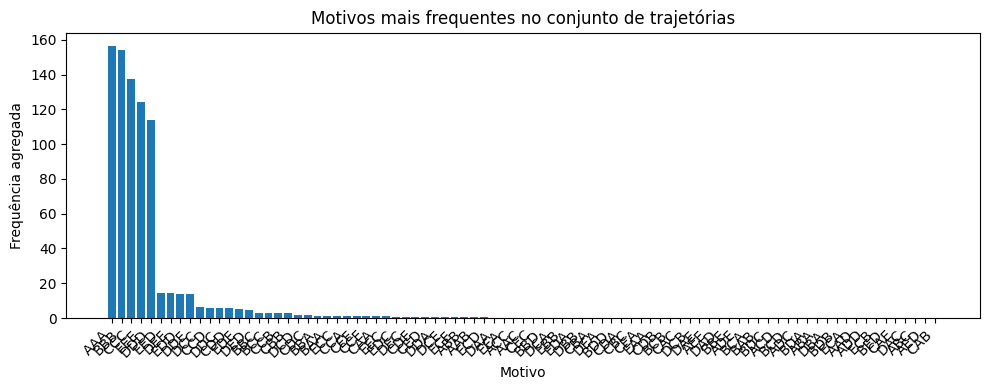

In [108]:
# ========================================================
# Frequência global dos motivos (motif_df já normalizado)
# ========================================================

import matplotlib.pyplot as plt

# --------------------------------------------------------
# Selecionar apenas colunas de motivos
# --------------------------------------------------------
motif_cols = [
    c for c in motif_df.columns
    if c not in ["user_id", "trajectory_id"]
]

# --------------------------------------------------------
# Soma das frequências relativas ao longo das trajetórias
# (equivale à frequência média ponderada por trajetória)
# --------------------------------------------------------
global_motif_freq = motif_df[motif_cols].sum().sort_values(ascending=False)

# --------------------------------------------------------
# Normalização opcional (percentual global)
# --------------------------------------------------------
global_motif_freq_pct = global_motif_freq / global_motif_freq.sum() * 100

# --------------------------------------------------------
# Print
# --------------------------------------------------------
freq_df = (
    global_motif_freq
    .to_frame(name="Frequência agregada")
    .assign(Frequência_percentual=global_motif_freq_pct)
)

print("Frequência global dos motivos (agregada em todas as trajetórias):")
display(freq_df.head(20))

# --------------------------------------------------------
# Plot
# --------------------------------------------------------
plt.figure(figsize=(10, 4))
plt.bar(freq_df.index, freq_df["Frequência agregada"])
plt.xlabel("Motivo")
plt.ylabel("Frequência agregada")
plt.title("Motivos mais frequentes no conjunto de trajetórias")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [109]:
from scipy.stats import entropy

motif_cols = motif_df.columns.difference(
    ["user_id", "trajectory_id"]
)

motif_df["entropy"] = motif_df[motif_cols].apply(
    lambda x: entropy(x[x > 0]),
    axis=1
)

motif_df["dominance"] = motif_df[motif_cols].max(axis=1)


In [110]:
import umap

embedding = umap.UMAP(
    n_neighbors=2,
    min_dist=0.1,
    random_state=42
).fit_transform(
    motif_df[["entropy", "dominance"]]
)

motif_df["umap_x"] = embedding[:, 0]
motif_df["umap_y"] = embedding[:, 1]


C:\Users\ccana\AppData\Roaming\Python\Python312\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


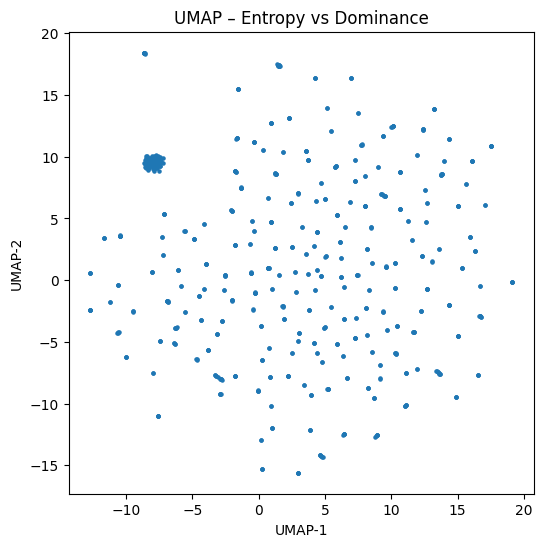

In [111]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(
    motif_df["umap_x"],
    motif_df["umap_y"],
    s=5
)
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title("UMAP – Entropy vs Dominance")
plt.show()


In [112]:
cluster = motif_df[
    (motif_df["umap_x"].between(7, 14)) &
    (motif_df["umap_y"].between(9, 17))
].copy()

cluster["is_cluster"] = True
motif_df["is_cluster"] = motif_df.index.isin(cluster.index)


In [113]:
from sklearn.linear_model import LinearRegression

'''def compute_vsl_slope(g):
    t = np.arange(len(g)).reshape(-1, 1)
    v = g["speed"].values.reshape(-1, 1)
    model = LinearRegression().fit(t, v)
    return model.coef_[0, 0]'''

def compute_vsl_slope(g):
    # Pega ponto inicial
    x0, y0 = g.iloc[0][["x", "y"]]
    
    # Calcula distância euclidiana do início até cada ponto t
    dists = np.sqrt((g["x"] - x0)**2 + (g["y"] - y0)**2)
    
    # Tempo (assumindo frames sequenciais como tempo)
    times = np.arange(1, len(g) + 1) # evita divisão por zero
    
    # VSL = Distancia Retilinea / Tempo
    vsl_series = dists / times
    
    # Regressão na série VSL
    model = LinearRegression().fit(times.reshape(-1, 1), vsl_series.values.reshape(-1, 1))
    return model.coef_[0, 0]

vsl_slope = (
    df
    .groupby(["user_id", "trajectory_id"])
    .apply(compute_vsl_slope)
    .reset_index(name="VSL_slope")
)


C:\Users\ccana\AppData\Local\Temp\ipykernel_42972\3526723073.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_vsl_slope)


In [114]:
analysis_df = motif_df.merge(
    vsl_slope,
    on=["user_id", "trajectory_id"]
)


In [115]:
from scipy.stats import mannwhitneyu

mannwhitneyu(
    analysis_df.loc[analysis_df.is_cluster, "VSL_slope"],
    analysis_df.loc[~analysis_df.is_cluster, "VSL_slope"],
    alternative="two-sided"
)


MannwhitneyuResult(statistic=8447.0, pvalue=0.01041344906230258)

In [116]:
analysis_df["AAA"] = analysis_df.get("AAA", 0)

analysis_df.groupby("is_cluster")["AAA"].mean()


is_cluster
False    0.198894
True     0.056122
Name: AAA, dtype: float64

In [117]:
summary = analysis_df.groupby("is_cluster").agg(
    VSL_median=("VSL_slope", "median"),
    VSL_iqr=("VSL_slope", lambda x: x.quantile(0.75) - x.quantile(0.25)),
    entropy_mean=("entropy", "mean"),
    entropy_std=("entropy", "std"),
    dominance_mean=("dominance", "mean"),
    dominance_std=("dominance", "std"),
    DDD_mean=("AAA", "mean"),
    DDD_std=("AAA", "std"),
    n_tracks=("trajectory_id", "count")
)

summary


,VSL_median,VSL_iqr,entropy_mean,entropy_std,dominance_mean,dominance_std,DDD_mean,DDD_std,n_tracks
is_cluster,,,,,,,,,
False,-1.697492e-08,4.376285e-07,0.890500,0.646714,0.717950,0.218823,0.198894,0.351255,777
True,-3.538167e-07,3.520309e-06,1.931444,0.650709,0.382313,0.202505,0.056122,0.184702,30


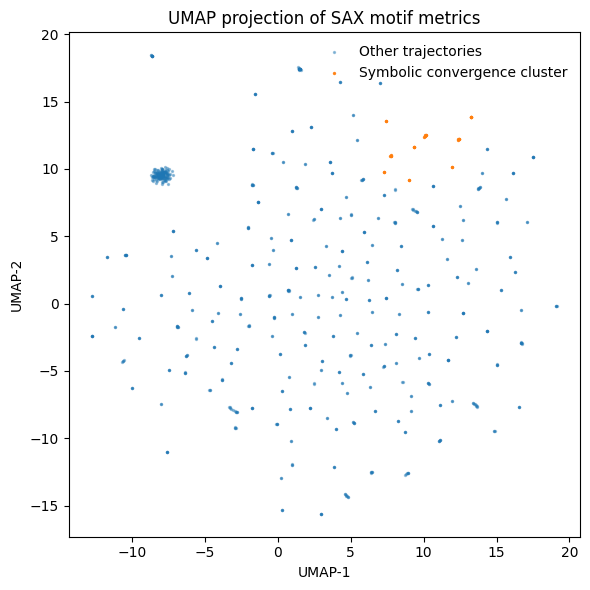

In [118]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

# Pontos fora do cluster compacto
plt.scatter(
    motif_df.loc[~motif_df["is_cluster"], "umap_x"],
    motif_df.loc[~motif_df["is_cluster"], "umap_y"],
    s=2,
    alpha=0.4,
    label="Other trajectories"
)

# Pontos do cluster compacto
plt.scatter(
    motif_df.loc[motif_df["is_cluster"], "umap_x"],
    motif_df.loc[motif_df["is_cluster"], "umap_y"],
    s=2,
    alpha=0.9,
    label="Symbolic convergence cluster"
)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title("UMAP projection of SAX motif metrics")
plt.legend(frameon=False)

plt.tight_layout()
plt.show()


In [119]:
# ========================================================
# Identificação das trajetórias no cluster DDD
# ========================================================

# Filtrar apenas trajetórias no cluster
ddd_trajs = analysis_df.loc[
    analysis_df["is_cluster"], 
    ["user_id", "trajectory_id"]
]

print(f"Número de trajetórias no cluster DDD: {len(ddd_trajs)}")
display(ddd_trajs)

ddd_trajs.to_csv(DATA_PROCESSED / "ddd_trajs.csv")

Número de trajetórias no cluster DDD: 30


,user_id,trajectory_id
44,11,cl4us4ype001h356pnyet3ts9
55,12,cl4usboop0031356pqrsxb2f6
76,12,cl4x16mfg000r356povntvh44
81,12,cl4xolkrv004o356pdssw4a9x
174,15,cl3jyjbuf006p3r6cmo04geoy
197,15,cl3jzfaz9009h3r6c2pqqbady
212,19,cl3k5ur8t000j3r6cj4lah4gn
214,19,cl3k5uzg8000r3r6crgufjvav
216,19,cl3k5vfqr000y3r6cttf33lc6
218,19,cl3k5wa0n001a3r6c0kq0w4yz
